Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


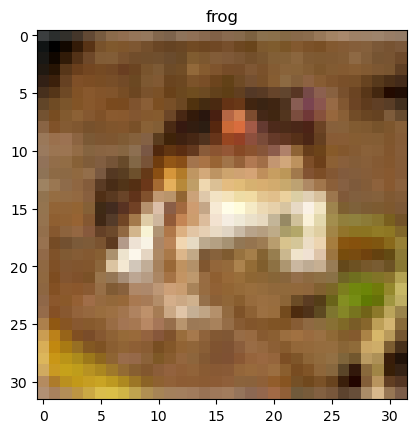

C:\Users\keert\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.4536 - loss: 1.4981 - val_accuracy: 0.5593 - val_loss: 1.2240
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.5995 - loss: 1.1332 - val_accuracy: 0.6355 - val_loss: 1.0323
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 20ms/step - accuracy: 0.6522 - loss: 0.9856 - val_accuracy: 0.6666 - val_loss: 0.9398
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6892 - loss: 0.8851 - val_accuracy: 0.6871 - val_loss: 0.8983
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.7181 - loss: 0.8075 - val_accuracy: 0.6969 - val_loss: 0.8780
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.7382 - loss: 0.7453 - val_accuracy: 0.6987 - val_loss: 0.8642
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.7546 - loss: 0.7006 - val_accuracy: 0.7041 - val_loss: 0.8529
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.7728 -

In [ ]:
# Import Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np


# Load CIFAR-10 Dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()


# Class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']


# Dataset shape check
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


# Show one image
plt.imshow(X_train[0])
plt.title(class_names[y_train[0][0]])
plt.show()


# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0


# Build CNN Model
model = keras.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])


# Model summary
model.summary()


# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)


# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)


# Predictions
predictions = model.predict(X_test)


# Show prediction for one image
plt.imshow(X_test[0])
plt.title("Predicted: " + class_names[np.argmax(predictions[0])])
plt.show()


# Show multiple predictions
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])
    plt.title(class_names[np.argmax(predictions[i])])
    plt.axis('off')

plt.show()